# Operator Analytics — the Precomputed Dashboard Payload

Module A of the platform. Notebook 01 explored the data interactively; this notebook
turns the same aggregations into a **single JSON file** the operator dashboard and the
API's `/analytics/*` endpoints read at request time. No pandas runs when a page loads —
`scripts/build_analytics.py` produces `data/processed/analytics.json` ahead of time, and
this notebook walks through what goes into it.

The functions live in `evcharging.analytics.aggregate`; each builds one section of the
payload.

## Contents

* Load the processed sessions
* `overview` — the KPI row
* `patterns` — time-of-day, weekday, charger, vehicle
* `locations` — the per-city table
* `segments` — cluster profiles
* `anomalies` — risk buckets
* Assemble and write `analytics.json`

## Load the processed sessions

In [1]:
import sys

sys.path.insert(0, "../src")

import pandas as pd

from evcharging.config import CLEAN_PARQUET

df = pd.read_parquet(CLEAN_PARQUET)
df.shape

(1320, 57)

## `overview` — the KPI row

The headline numbers: session count, total and average energy, average duration and
cost, the peak hour (by mean energy, since session counts are flat on this grid), the
most-used charger, the highest-demand city, and a data-quality line so the dashboard can
show honestly how many sessions fail validation.

In [2]:
from evcharging.analytics import overview

ov = overview(df)
ov

{'n_sessions': 1320,
 'date_start': '2024-01-01',
 'date_end': '2024-02-24',
 'n_stations': 462,
 'n_locations': 5,
 'n_vehicle_models': 5,
 'total_energy_kwh': 53474.19,
 'mean_energy_kwh': 42.64,
 'median_energy_kwh': 42.69,
 'mean_duration_hours': 2.23,
 'total_cost_usd': 29767.78,
 'mean_cost_usd': 22.55,
 'mean_charging_rate_kw': 25.96,
 'mean_soc_increase_pct': 26.01,
 'peak_hour': 4,
 'most_used_charger_type': 'Level 1',
 'highest_demand_location': 'Los Angeles',
 'data_quality': {'n_sessions_flagged': 1296, 'pct_sessions_flagged': 98.2}}

**Observations**

* ~1,320 sessions delivering ~53 MWh over the 55 days, averaging ~43 kWh and ~\$23 each.
* `pct_sessions_flagged` is ~98% — the dashboard surfaces this rather than hiding it.
* `peak_hour` and `highest_demand_location` are weak signals here (the data is close to
  uniform) but the fields are what a real network needs.

## `patterns` — time-of-day, weekday, charger, vehicle

In [3]:
from evcharging.analytics import patterns

pat = patterns(df)
list(pat)

['by_hour',
 'by_weekday',
 'by_charger_type',
 'by_vehicle_model',
 'weekend_vs_weekday']

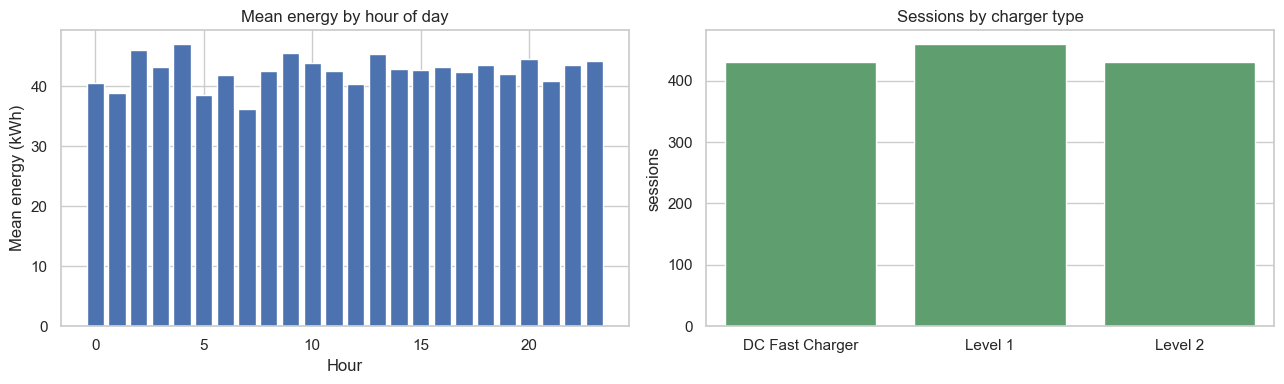

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

by_hour = pd.DataFrame(pat["by_hour"])
by_charger = pd.DataFrame(pat["by_charger_type"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(by_hour["hour"], by_hour["mean_energy_kwh"], color="#4C72B0")
axes[0].set_title("Mean energy by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean energy (kWh)")

sns.barplot(data=by_charger, x="charger_type", y="sessions", ax=axes[1], color="#55A868")
axes[1].set_title("Sessions by charger type")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

In [5]:
pd.DataFrame(pat["by_vehicle_model"])

,vehicle_model,sessions,mean_energy_kwh,mean_battery_capacity_kwh,mean_distance_km
0,BMW i3,258,42.45,76.78,147.31
1,Chevy Bolt,256,40.74,73.91,156.69
2,Hyundai Kona,266,42.83,75.40,161.29
3,Nissan Leaf,260,42.51,72.84,145.81
4,Tesla Model 3,280,44.52,73.80,156.70


In [6]:
pd.DataFrame(pat["weekend_vs_weekday"]).T

,sessions,mean_energy_kwh,mean_duration_hours,mean_cost_usd
weekday,960.0,42.06,2.24,22.91
weekend,360.0,44.15,2.19,21.59


**Observations**

* Mean energy by hour is flat within noise; the three charger types are used about
  equally and their energy/cost profiles barely differ (a property of the synthetic
  data, noted in notebook 01).
* Weekend and weekday sessions look identical on every metric.

## `locations` — the per-city table

In [7]:
from evcharging.analytics import locations

loc_df = pd.DataFrame(locations(df))
loc_df

,location,sessions,n_stations,total_energy_kwh,mean_energy_kwh,mean_duration_hours,mean_cost_usd
0,Los Angeles,297,219,11507.73,41.39,2.23,22.54
1,Houston,262,201,11031.49,44.13,2.31,22.09
2,San Francisco,264,199,10497.37,42.16,2.18,21.99
3,New York,255,204,10261.60,42.23,2.20,22.50
4,Chicago,242,193,10176.00,43.49,2.21,23.72


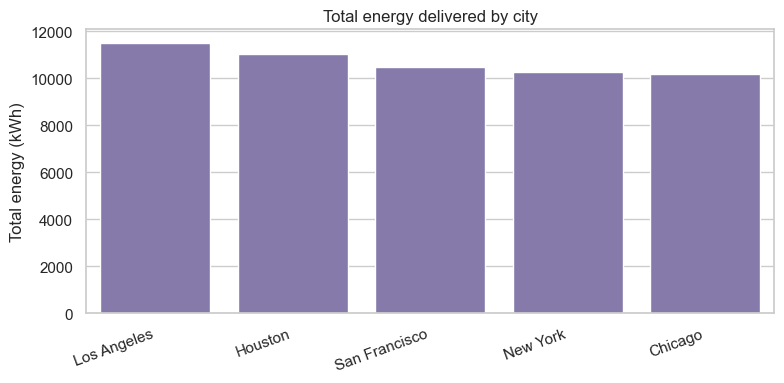

In [8]:
plt.figure(figsize=(8, 4))
sns.barplot(data=loc_df, x="location", y="total_energy_kwh", color="#8172B2")
plt.title("Total energy delivered by city")
plt.xlabel("")
plt.ylabel("Total energy (kWh)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Observations**

* The five cities are within ~15% of each other on total energy; the ranking is driven by
  session count, not by any per-session difference.
* `n_stations` per city (~90–220) confirms the ~2.8-sessions-per-station sparsity that
  rules out per-station modelling.

## `segments` — cluster profiles

`segments` loads the fitted segmenter from `session_segmenter.joblib`, labels every
session, and returns each cluster's mean profile with its archetype name — the table
behind the dashboard's "Session Segments" page.

In [9]:
from evcharging.analytics.aggregate import segments
from evcharging.models.common import load_artifact

segmenter_bundle = load_artifact("session_segmenter.joblib")
seg_df = pd.DataFrame(segments(df, segmenter_bundle)).set_index("archetype")
seg_df

,cluster,n_sessions,energy_kwh,duration_hours,distance_km,soc_delta_pct,charging_rate_kw,cost_usd
archetype,,,,,,,,
Short fast high-energy sessions,0,340,62.06,2.13,140.37,34.15,25.42,13.34
Long fast low-energy sessions,1,316,31.11,2.61,209.90,24.57,39.69,23.88
Short slow high-energy sessions,2,343,52.46,1.88,123.56,26.46,23.49,33.70
Long slow low-energy sessions,3,321,22.91,2.32,142.87,18.34,15.41,19.09


## `anomalies` — risk buckets

`anomalies` takes the per-session anomaly scores and splits them into high / medium /
normal risk, plus the five worst sessions for the dashboard's Anomaly Monitor.

In [10]:
from evcharging.analytics.aggregate import anomalies
from evcharging.models.anomaly import fit_anomaly

scores = fit_anomaly(df).scores
anom = anomalies(df, scores)
{k: v for k, v in anom.items() if k != "worst_sessions"}

{'n_high_risk': 33,
 'n_medium_risk': 97,
 'n_normal': 1190,
 'score_bins': {'high': '>= 0.60',
  'medium': '0.40 - 0.60',
  'normal': '< 0.40'}}

In [11]:
pd.DataFrame(anom["worst_sessions"])

,index,station_id,location,vehicle_model,energy_kwh,battery_capacity_kwh,soc_delta_pct,anomaly_score
0,0.0,Station_372,Los Angeles,BMW i3,0.05,100.0,24.12,1.00
1,1.0,Station_246,Chicago,Nissan Leaf,0.12,62.0,-9.11,0.95
2,2.0,Station_469,New York,Nissan Leaf,5.01,85.0,80.49,0.83
3,3.0,Station_192,Los Angeles,Chevy Bolt,1.36,100.0,42.15,0.82
4,4.0,Station_322,San Francisco,Hyundai Kona,48.61,50.0,-59.41,0.76


## Assemble and write `analytics.json`

In [12]:
from evcharging.analytics import build_analytics, write_analytics
from evcharging.config import ANALYTICS_JSON

payload = build_analytics(df, segmenter_bundle=segmenter_bundle, anomaly_scores=scores)
write_analytics(payload)

print("sections:", list(payload))
print("written to:", ANALYTICS_JSON.name)

sections: ['generated_at', 'overview', 'patterns', 'locations', 'segments', 'anomalies']
written to: analytics.json


In [13]:
import json

# round-trip check: the payload is valid JSON with no numpy types
reloaded = json.loads(json.dumps(payload))
assert reloaded["overview"]["n_sessions"] == len(df)
assert len(reloaded["patterns"]["by_hour"]) == 24
assert len(reloaded["segments"]) == 4
reloaded["overview"]

{'n_sessions': 1320,
 'date_start': '2024-01-01',
 'date_end': '2024-02-24',
 'n_stations': 462,
 'n_locations': 5,
 'n_vehicle_models': 5,
 'total_energy_kwh': 53474.19,
 'mean_energy_kwh': 42.64,
 'median_energy_kwh': 42.69,
 'mean_duration_hours': 2.23,
 'total_cost_usd': 29767.78,
 'mean_cost_usd': 22.55,
 'mean_charging_rate_kw': 25.96,
 'mean_soc_increase_pct': 26.01,
 'peak_hour': 4,
 'most_used_charger_type': 'Level 1',
 'highest_demand_location': 'Los Angeles',
 'data_quality': {'n_sessions_flagged': 1296, 'pct_sessions_flagged': 98.2}}

## Summary / Key Takeaways

* `evcharging.analytics.aggregate` turns the processed sessions into a five-section
  dashboard payload: `overview`, `patterns`, `locations`, `segments`, `anomalies`.
* `scripts/build_analytics.py` writes it to `data/processed/analytics.json`; the Phase-4
  API serves it read-only, so no aggregation runs per request.
* The payload includes a data-quality line, so the dashboard can be honest about the
  ~98% validation-failure rate rather than hiding it.
* This is the last Phase-1–3 notebook. Phase 4 wraps the models and this payload in a
  FastAPI service.